# Chapter 4 — SI Model (Social Influence)
**Modeling Social Behavior** | Smaldino

---

### What this notebook does

We build the **SI (Susceptible → Infected) model** from Section 4.3.  
This is a direct extension of the Spontaneous Adoption model, with one crucial addition:  
**agents can now infect each other through physical proximity.**

New mechanics compared to the spontaneous model:
- Each susceptible agent counts how many **infected neighbors** are within radius *r*
- The probability of becoming infected depends on **both** the number of infected neighbors (via transmissibility τ) **and** a spontaneous infection rate α
- The combined infection probability uses the **complementary probability formula** from Equation 4.3:

$$\Pr(\text{infection}) = 1 - (1 - \tau)^n \cdot (1 - \alpha)$$

where *n* is the number of infected neighbors within radius *r*.

We also derive and compare the **analytical SI model** (Equation 4.8).


---
## 1. Imports and Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mesa import Agent, Model
from mesa.space import ContinuousSpace
from mesa.datacollection import DataCollector

np.random.seed(42)
print("All imports successful.")


All imports successful.


---
## 2. The Agent Class

Compared to the Spontaneous Adoption agent, the SI agent has one new responsibility:
**check for infected neighbors within radius *r* and compute the combined infection probability.**

### Variable types
| Variable | Type | Description |
|---|---|---|
| `self.infected` | Agent-level | Whether this agent has been infected |
| `self.heading` | Agent-level | Current movement direction (radians) |
| `self.pos` | Agent-level | Current (x, y) position — managed by Mesa |

### The core infection formula

The book derives this in Section 4.3.1 (Equation 4.3).  
We want the probability that **at least one** of *n* infected neighbors transmits:

$$\Pr(\text{infection from neighbors}) = 1 - (1 - \tau)^n$$

But this model also keeps a spontaneous infection channel (α), so a susceptible agent can  
become infected either from a neighbor OR spontaneously. These are independent events, so:

$$\Pr(\text{infection}) = 1 - (1 - \tau)^n \cdot (1 - \alpha)$$

Reading this: the only way to **not** get infected is to escape both channels simultaneously: 
escape all *n* neighbors (probability $(1-\tau)^n$) AND escape spontaneous adoption (probability $(1-\alpha)$).


In [3]:
class SIAgent(Agent):
    """
    A single agent in the SI contagion model.

    Agent-level variables:
        infected  (bool)  -- True if this agent has been infected
        heading   (float) -- Current movement direction in radians (0 to 2π)
    """

    def __init__(self, model):
        super().__init__(model)

        # AGENT VARIABLE: infection status — starts susceptible
        self.infected = False

        # AGENT VARIABLE: movement heading — random initial direction
        self.heading = self.random.uniform(0, 2 * np.pi)

    def step(self):
        # Order matches the book: infection check first, then move
        self._try_infection()
        self._move()

    # ------------------------------------------------------------------
    # INFECTION — SOCIAL INFLUENCE + SPONTANEOUS
    # ------------------------------------------------------------------
    def _try_infection(self):
        """
        Compute the probability of becoming infected this step, combining:
          1. Social influence: each infected neighbor within radius r independently
             tries to transmit with probability tau (transmissibility).
          2. Spontaneous adoption: independent of neighbors, with probability alpha.

        Combined formula (Eq. 4.3 extended):
            Pr(infection) = 1 - (1 - tau)^n * (1 - alpha)

        where n = number of infected neighbors within radius r.

        The logic: the ONLY way to stay susceptible is to escape BOTH channels.
        """
        if self.infected:
            return  # already infected — nothing to do

        # LOCAL VARIABLE: neighbors — all agents within infection radius r
        # ContinuousSpace.get_neighbors returns agents whose position is within
        # `radius` of this agent. include_center=False excludes the agent itself.
        neighbors = self.model.space.get_neighbors(
            self.pos, self.model.infection_radius, include_center=False
        )

        # LOCAL VARIABLE: n_infected — count only the infected ones among neighbors
        # These are the agents who might transmit the contagion this step.
        n_infected = sum(1 for nb in neighbors if nb.infected)

        # LOCAL VARIABLE: p_infection — combined probability of becoming infected
        # Break it down:
        #   (1 - tau)^n_infected  →  probability ALL infected neighbors FAIL to transmit
        #   (1 - alpha)           →  probability spontaneous adoption also FAILS
        #   Multiplied: probability of escaping BOTH channels
        #   1 - that product: probability of being infected by AT LEAST ONE channel
        p_escape_neighbors   = (1 - self.model.tau) ** n_infected
        p_escape_spontaneous = (1 - self.model.alpha)
        p_infection = 1 - (p_escape_neighbors * p_escape_spontaneous)

        # Flip the coin: become infected with probability p_infection
        if self.random.random() < p_infection:
            self.infected = True

    # ------------------------------------------------------------------
    # MOVEMENT — CORRELATED RANDOM WALK (same as spontaneous model)
    # ------------------------------------------------------------------
    def _move(self):
        """
        Nudge heading by a random amount within ±(turning_angle/2),
        then step forward by `speed`. Toroidal wrapping is handled by Mesa.
        """
        # LOCAL VARIABLE: max_turn — half the turning angle in radians
        max_turn = np.radians(self.model.turning_angle) / 2
        self.heading += self.random.uniform(-max_turn, max_turn)

        # LOCAL VARIABLES: dx, dy — displacement vector
        dx = self.model.speed * np.cos(self.heading)
        dy = self.model.speed * np.sin(self.heading)

        new_x = self.pos[0] + dx
        new_y = self.pos[1] + dy
        self.model.space.move_agent(self, (new_x, new_y))


---
## 3. The Model Class

Two new global parameters compared to the spontaneous model:
- **`tau`** (τ) — transmissibility: per-contact infection probability
- **`infection_radius`** (*r*) — the spatial distance within which agents can infect each other

`alpha` is kept at 0 by default (pure social influence), but can be set above 0 to combine  
spontaneous and social channels, exactly as the book's model does.

### Variable types
| Variable | Type | Description |
|---|---|---|
| `N` | Global | Total number of agents |
| `init_infected` | Global | Number of seed infections at t=0 |
| `tau` | Global | Transmissibility — per-contact infection probability (τ) |
| `alpha` | Global | Spontaneous infection rate (α), default 0 |
| `infection_radius` | Global | Distance within which infected agents can transmit |
| `speed` | Global | Movement distance per step |
| `turning_angle` | Global | Maximum heading change per step (degrees) |


In [4]:
class SIModel(Model):
    """
    The SI contagion model with social influence.

    Global parameters:
        N                (int)   -- total number of agents
        init_infected    (int)   -- number of seed infections at t=0
        tau              (float) -- transmissibility (per-contact infection probability)
        alpha            (float) -- spontaneous infection rate (default 0 = pure SI)
        infection_radius (float) -- spatial radius for neighbor detection
        speed            (float) -- movement distance per step
        turning_angle    (float) -- max heading change per step, in degrees
        width, height    (float) -- size of the 2-D toroidal space
    """

    def __init__(
        self,
        N=300,
        init_infected=3,
        tau=0.05,
        alpha=0.0,
        infection_radius=1.0,
        speed=0.5,
        turning_angle=60,
        width=33,
        height=33,
    ):
        super().__init__()

        # ── GLOBAL VARIABLES ──────────────────────────────────────────
        self.N = N
        self.init_infected = init_infected
        self.tau = tau                        # transmissibility (τ)
        self.alpha = alpha                    # spontaneous infection rate (α)
        self.infection_radius = infection_radius
        self.speed = speed
        self.turning_angle = turning_angle
        self.running = True

        # ── SPACE ─────────────────────────────────────────────────────
        self.space = ContinuousSpace(width, height, torus=True)

        # ── CREATE AND PLACE AGENTS ───────────────────────────────────
        for _ in range(self.N):
            agent = SIAgent(self)
            x = self.random.uniform(0, width)
            y = self.random.uniform(0, height)
            self.space.place_agent(agent, (x, y))

        # ── SEED INITIAL INFECTIONS ───────────────────────────────────
        n_seed = min(self.init_infected, self.N)
        seeds = list(self.agents)[:n_seed]
        for agent in seeds:
            agent.infected = True

        # ── DATA COLLECTOR ────────────────────────────────────────────
        self.datacollector = DataCollector(
            model_reporters={
                "proportion_infected": lambda m: sum(
                    1 for a in m.agents if a.infected
                ) / m.N
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """
        One time step: activate all agents in random order, collect data,
        then check the stop condition.
        """
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

        # Stop when the entire population is infected
        if sum(1 for a in self.agents if a.infected) == self.N:
            self.running = False

    def run(self, max_steps=500):
        """Run up to max_steps steps. Returns a pandas DataFrame of recorded data."""
        for _ in range(max_steps):
            if not self.running:
                break
            self.step()
        return self.datacollector.get_model_vars_dataframe()


---
## 4. The Analytical SI Model (Equation 4.8)

The analytical SI model assumes a **well-mixed population** where interactions are completely  
random, so the probability of a susceptible agent encountering an infected one is simply  
the current frequency of infected agents in the population (I/N).

The difference equation (derived in Section 4.4, Eq. 4.8) is:

$$I_{t+1} = I_t + \tau I_t \left(1 - \frac{I_t}{N}\right)$$

Compare this to the spontaneous model's Eq. 4.1:

$$I_{t+1} = I_t + \alpha (N - I_t)$$

The key difference: in the spontaneous model, new infections scale with **α** (a fixed rate).  
In the SI model, new infections scale with **τ × I_t / N** — the current density of infected agents.  
This is what makes the SI model a true *social* contagion: the more people are infected, the faster it spreads.

### Variables
| Variable | Type | Description |
|---|---|---|
| `N` | Parameter | Total population size |
| `tau` | Parameter | Transmissibility (τ) |
| `I0` | Parameter | Initial infected count |
| `n_steps` | Parameter | Number of steps to compute |
| `I` | Local | List accumulating I_t over time |


In [5]:
def analytical_SI(N, tau, I0, n_steps):
    """
    Numerically solves the SI difference equation (Eq. 4.8):

        I_{t+1} = I_t + tau * I_t * (1 - I_t / N)

    Parameters
    ----------
    N       : int   -- total population size
    tau     : float -- transmissibility
    I0      : int   -- initial number of infected agents
    n_steps : int   -- number of time steps to compute

    Returns
    -------
    proportion : np.ndarray
        Array of length n_steps+1 giving the proportion infected (I_t / N)
        at each time step.
    """
    # LOCAL VARIABLE: I — list of infected counts, built step by step
    I = [I0]

    for t in range(n_steps):
        # LOCAL VARIABLE: I_t — current infected count
        I_t = I[-1]

        # New infections this step:
        #   tau * I_t         →  rate proportional to current infected density
        #   (1 - I_t / N)     →  fraction of population still susceptible
        # Together: new infections = tau * I_t * (susceptible fraction)
        new_infections = tau * I_t * (1 - I_t / N)

        I_next = I_t + new_infections
        I.append(I_next)

    return np.array(I) / N   # convert counts to proportions


# ── Sanity check ─────────────────────────────────────────────────────────────
curve = analytical_SI(N=300, tau=0.05, I0=3, n_steps=200)
print("Analytical SI curve (N=300, τ=0.05, I0=3):")
print(f"  t=0:    {curve[0]:.4f}")
print(f"  t=50:   {curve[50]:.4f}")
print(f"  t=200:  {curve[200]:.4f}  (should approach 1.0)")


Analytical SI curve (N=300, τ=0.05, I0=3):
  t=0:    0.0100
  t=50:   0.1043
  t=200:  0.9956  (should approach 1.0)


---
## 5. Run the Agent-Based Simulation

**Default parameters** (matching the book's SI model defaults):

| Parameter | Value | Notes |
|---|---|---|
| N | 300 | Population size |
| init_infected | 3 | Three seed infections |
| τ (tau) | 0.05 | Transmissibility per contact |
| α (alpha) | 0.0 | No spontaneous infection — pure social influence |
| infection_radius | 1.0 | Spatial radius for neighbor detection |
| speed | 0.5 | Distance per step |
| turning_angle | 60° | Moderate movement correlation |

Setting α = 0 gives us the **pure SI model** — adoption only spreads through direct contact.  
Later we will explore what happens when we add a spontaneous channel (α > 0).


In [6]:
# ── GLOBAL PARAMETERS ────────────────────────────────────────────────────────
N                = 300    # total population
init_infected    = 3      # seed infections
tau              = 0.05   # transmissibility (τ)
alpha            = 0.0    # spontaneous infection rate (α) — set to 0 for pure SI
infection_radius = 1.0    # spatial radius for neighbor detection
speed            = 0.5    # movement speed
turning_angle    = 60     # max heading change per step (degrees)

# ── RUN ───────────────────────────────────────────────────────────────────────
print("Running SI agent-based simulation...")
model = SIModel(
    N=N,
    init_infected=init_infected,
    tau=tau,
    alpha=alpha,
    infection_radius=infection_radius,
    speed=speed,
    turning_angle=turning_angle,
)
sim_data = model.run(max_steps=500)

n_steps_sim = len(sim_data) - 1
print(f"Simulation finished after {n_steps_sim} steps.")
print(f"Final proportion infected: {sim_data['proportion_infected'].iloc[-1]:.4f}")


Running SI agent-based simulation...
Simulation finished after 257 steps.
Final proportion infected: 1.0000


---
## 6. Plot: Simulation vs. Analytical Prediction

We overlay:
- **Red line** — agent-based simulation
- **Grey line** — analytical prediction (Eq. 4.8)

The analytical model assumes perfect well-mixing, so it will be a smoother curve.  
The simulation may deviate slightly due to spatial structure and stochasticity —  
this is the difference Figure 4.6 illustrates in the book.


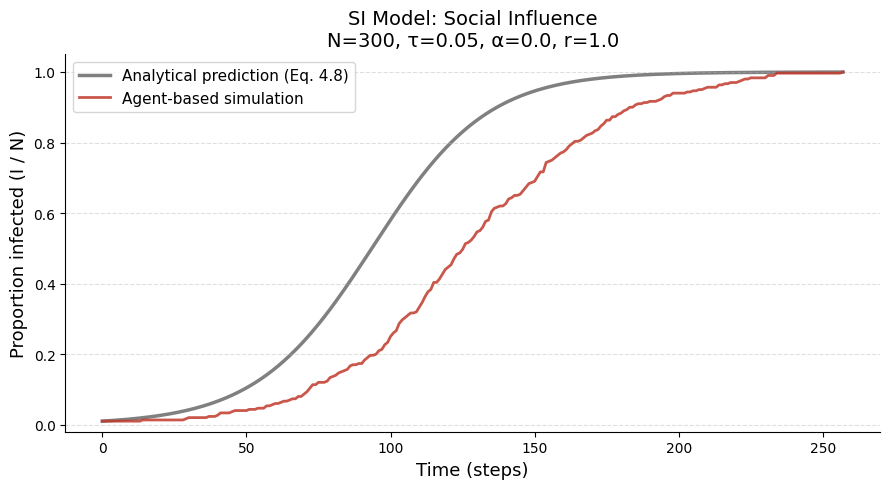

In [7]:
# Compute analytical curve for the same number of steps the simulation ran
analytical = analytical_SI(N, tau, init_infected, n_steps_sim)

fig, ax = plt.subplots(figsize=(9, 5))

time_steps = np.arange(n_steps_sim + 1)

# Analytical prediction (grey, behind)
ax.plot(
    time_steps,
    analytical,
    color="grey",
    linewidth=2.5,
    label="Analytical prediction (Eq. 4.8)",
    zorder=1,
)

# Simulation output (red, on top)
ax.plot(
    time_steps,
    sim_data["proportion_infected"].values,
    color="#c0392b",
    linewidth=2,
    alpha=0.85,
    label="Agent-based simulation",
    zorder=2,
)

ax.set_xlabel("Time (steps)", fontsize=13)
ax.set_ylabel("Proportion infected (I / N)", fontsize=13)
ax.set_title(
    f"SI Model: Social Influence\n"
    f"N={N}, τ={tau}, α={alpha}, r={infection_radius}",
    fontsize=14,
)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


---
## 7. Parameter Exploration: Effect of τ (Transmissibility)

Higher τ means each contact is more likely to result in infection.  
As the book discusses (Figure 4.7), τ controls the **speed** of the S-curve,  
not its final destination — all values of τ eventually lead to full infection in the SI model.

> 💡 Notice that the curves all have the same S-shape. Compare this to the  
> spontaneous model where α played the same role — this is because in both models,  
> spread is ultimately limited by the shrinking pool of susceptibles.


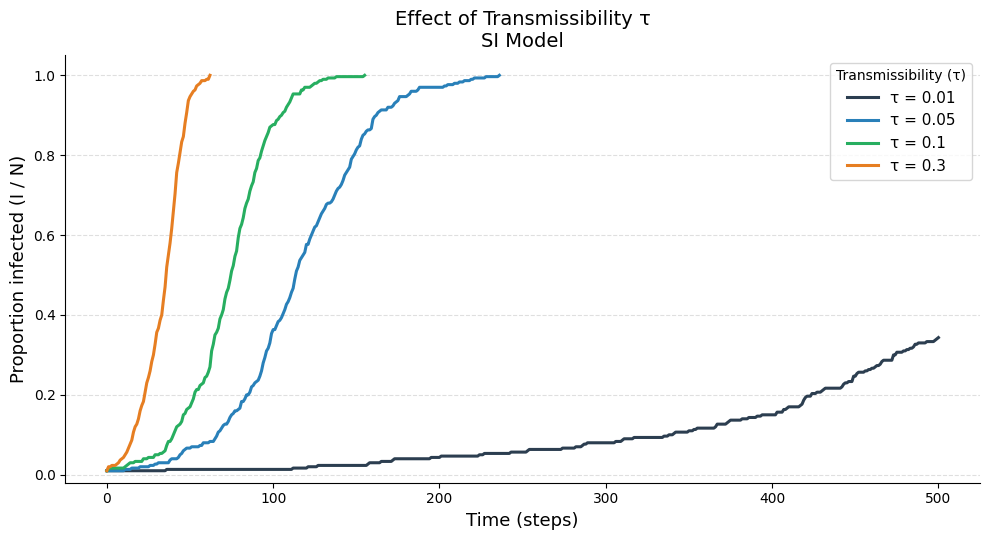

In [8]:
# GLOBAL VARIABLE: tau_values — set of transmissibility values to explore
tau_values = [0.01, 0.05, 0.1, 0.3]
colors     = ["#2c3e50", "#2980b9", "#27ae60", "#e67e22"]

fig, ax = plt.subplots(figsize=(10, 5.5))

for tau_val, color in zip(tau_values, colors):
    # LOCAL VARIABLE: m — one fresh model run per tau value
    m = SIModel(
        N=N,
        init_infected=init_infected,
        tau=tau_val,
        alpha=0.0,
        infection_radius=infection_radius,
        speed=speed,
        turning_angle=turning_angle,
    )
    data = m.run(max_steps=500)
    steps = len(data) - 1
    t = np.arange(steps + 1)

    ax.plot(t, data["proportion_infected"].values,
            color=color, linewidth=2.2, label=f"τ = {tau_val}")

ax.set_xlabel("Time (steps)", fontsize=13)
ax.set_ylabel("Proportion infected (I / N)", fontsize=13)
ax.set_title("Effect of Transmissibility τ\nSI Model", fontsize=14)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=11, title="Transmissibility (τ)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


---
## 8. Combining Social Influence and Spontaneous Adoption

The book's SI model code (`infect-susceptibles`) actually **combines both channels** in one formula:

$$\Pr(\text{infection}) = 1 - (1-\tau)^n \cdot (1-\alpha)$$

When α = 0 this is the pure SI model. When τ = 0 this reduces to the spontaneous model.  
We can run both channels simultaneously to see how they interact.

**What to observe:**
- Adding even a small α gives the contagion a "head start" before social influence kicks in
- The curves reach full infection faster when both channels are active
- This is a realistic scenario: some people adopt innovations independently, and then social exposure accelerates the rest


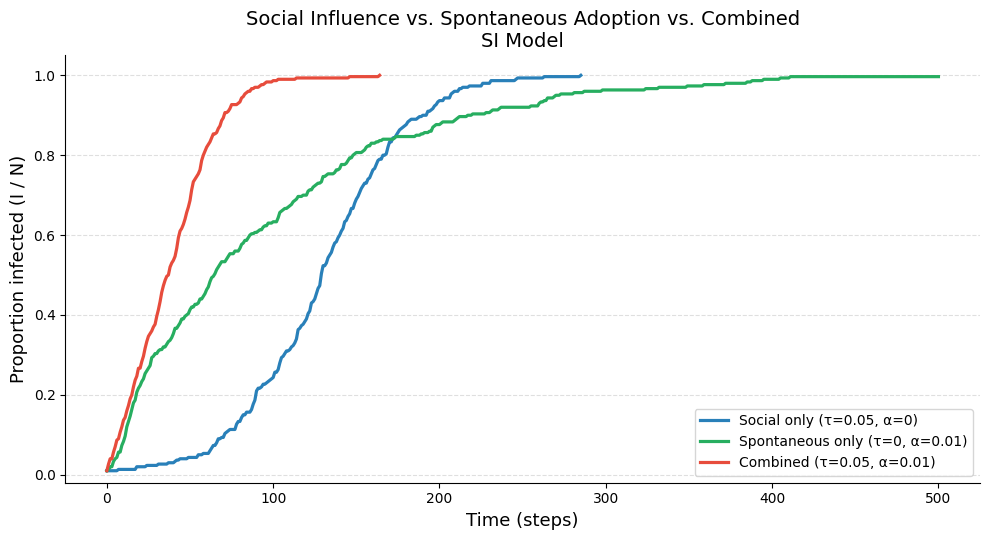

In [9]:
# We compare three scenarios:
#   1. Pure social influence (tau=0.05, alpha=0)
#   2. Pure spontaneous     (tau=0,    alpha=0.01)
#   3. Combined             (tau=0.05, alpha=0.01)

scenarios = [
    {"tau": 0.05, "alpha": 0.00, "label": "Social only (τ=0.05, α=0)",    "color": "#2980b9"},
    {"tau": 0.00, "alpha": 0.01, "label": "Spontaneous only (τ=0, α=0.01)", "color": "#27ae60"},
    {"tau": 0.05, "alpha": 0.01, "label": "Combined (τ=0.05, α=0.01)",     "color": "#e74c3c"},
]

fig, ax = plt.subplots(figsize=(10, 5.5))

for sc in scenarios:
    # LOCAL VARIABLE: m — one model run per scenario
    m = SIModel(
        N=N,
        init_infected=init_infected,
        tau=sc["tau"],
        alpha=sc["alpha"],
        infection_radius=infection_radius,
        speed=speed,
        turning_angle=turning_angle,
    )
    data = m.run(max_steps=500)
    steps = len(data) - 1
    t = np.arange(steps + 1)

    ax.plot(t, data["proportion_infected"].values,
            color=sc["color"], linewidth=2.3, label=sc["label"])

ax.set_xlabel("Time (steps)", fontsize=13)
ax.set_ylabel("Proportion infected (I / N)", fontsize=13)
ax.set_title("Social Influence vs. Spontaneous Adoption vs. Combined\nSI Model", fontsize=14)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


---
## 9. Reflection and Key Takeaways

### What changed from the Spontaneous model

| Feature | Spontaneous Model | SI Model |
|---|---|---|
| Requires contact to spread? | ❌ No | ✅ Yes |
| Key parameter | α (spontaneous rate) | τ (transmissibility) |
| New infections scale with... | α × susceptibles | τ × infected density × susceptibles |
| Location matters? | No | ✅ Yes — proximity drives contact |

### Why the S-curve still appears

The reason is the same as in the spontaneous model — the **pool of susceptibles shrinks**  
— but now there is an additional feedback loop: **more infected → more contacts → faster spread**.  
This creates a steeper middle section in the SI curve compared to the spontaneous model.

### Limitations of this model

- **No recovery** — the SI model still assumes permanent infection. The SIS and SIR models (next exercises) will fix this.
- **Perfect well-mixing ignored** — our ABM captures spatial clustering; the analytical model does not. This is why the two curves don't overlap as perfectly as in the spontaneous model.
- **Homogeneous agents** — all agents have the same τ. Real populations have variation in susceptibility and contagiousness.

### What comes next

The next model adds **recovery** (γ), transforming this into the **SIS model** —  
where infected agents can return to the susceptible pool, creating a dynamic equilibrium  
rather than full saturation.
